In [1]:
import ui
import construct
import ifc

import ui.comms

from configs.system_config import *
from configs.construction_config import *

import construct.analysis as analysis
 
from ui.mobility import moveJ, moveL, translate, set_orientation, gripper_width
# from construct.marker_pose import align_with_random_part
from construct.construction import rotation_matrix_to_vector
import ui.MarkerDetectionLocalization as mdl

from ui.comms import QuestionBoard
import matplotlib.pyplot as plt

import os

# import time
# ui.show_project_structure()

[FrameHandler] Connecting to ws://localhost:9090 ...
[FrameHandler] WebSocket connection opened.
[FrameHandler] Advertised topic: /image
[FrameHandler] Subscribed to topic: /image
Robot data listener started on ipc:///tmp/robot.ipc...
Listening for tracking messages...
[FrameHandler] Connecting to ws://localhost:9090 ...
[FrameHandler] WebSocket connection opened.
[FrameHandler] Advertised topic: /image
[FrameHandler] Subscribed to topic: /image


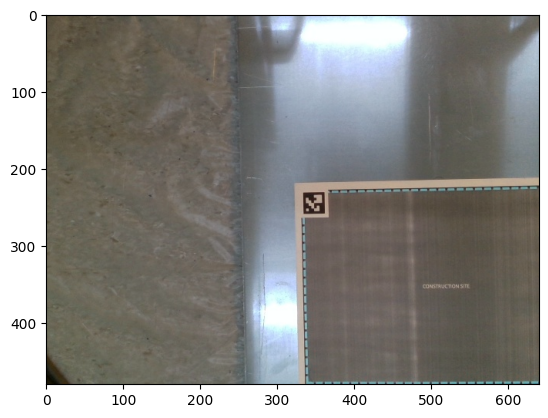

[FrameHandler] WebSocket error: Connection to remote host was lost.
[FrameHandler] WebSocket connection closed.
[FrameHandler] WebSocket error: Connection to remote host was lost.
[FrameHandler] WebSocket connection closed.


In [2]:
framehandler = ui.initializeUI()
packet = ui.comms.get_current_packet()
packet
files = []

In [ ]:
# Construction
board = QuestionBoard(bg="white") 

if not construct.check_resume():
    ui.comms.refresh_tracking_packets() #Refresh stored data

script_args = ["_workingdata/_siteinfo/IFC/Project1-06-UR3-v1.ifc", "--debug"]
IFC_sorted = ifc.IFC_loaded_sorted(*script_args)

block_list, pl_pos,verfied,img = construct.construct_and_verify(board, framehandler, IFC_sorted)

if not verfied:
    plt.imshow(img)
    plt.show()
    path = ui.comms.save_failed_run("assembly_run",block_list, pl_pos,img)
    files.append(path)

else:   
    assembly_data = ui.load_data(10) 

board.close() # All done

Performing site scan


In [4]:
# Deconstruction
file_index = "00"
file_base = "_workingdata/_siteinfo/_failedruns"
os.makedirs(file_base, exist_ok=True)

ui.comms.refresh_tracking_packets() #Refresh stored data

if not construct.check_resume():
    saved_paths = None
else:
    saved_paths = ui.comms.get_saved_paths(file_base, file_index)

dis_pos = construct.disassembly(
    pl_pos,
    block_list,
    framehandler,
    saved_paths=saved_paths
)

disassembly_data = ui.load_data(10)

Using stub file for site scan
Finished scanning
Unable to find fiducial marker. Please check the setup.
Finished deconstruction!


In [5]:
#Reconstruct
board = QuestionBoard(bg="white") 

if not construct.check_resume():
    ui.comms.refresh_tracking_packets() #Refresh stored data

script_args = ["_workingdata/_siteinfo/IFC/Project1-06-UR3-v2.ifc","--debug"]
IFC_sorted = ifc.IFC_loaded_sorted(*script_args)

block_list, pl_pos,verfied,img = construct.reconstruct_and_verify(board,dis_pos,framehandler, IFC_sorted)

if not verfied:
    plt.imshow(img)
    plt.show()
    ui.comms.save_failed_run("reassembly_run",block_list, pl_pos,img)
else:      
    reassembly_data = ui.load_data(10) 

board.close() # All done

Using stub file for site scan
Finished scanning
We should now place a colored toilet!
Red found = True
Blue found = True
Placing toilet on Foundation
Searching for Wall_1
The item is here:
Unable to find fiducial marker. Please check the setup.
Unable to find fiducial marker. Please check the setup.
Searching for Floor_1
The item is here:
Unable to find fiducial marker. Please check the setup.
Unable to find fiducial marker. Please check the setup.
We should now place a colored toilet!
Red found = True
Blue found = True
Placing toilet on floor
Second bathroom
I am at: [0.5752916947151762, 0.3086476628913604, 0.4517786549139613]
Now, I am at: [0.5768831754413788, 0.29648753274787265, 0.4515714829282395]
Ground: 0.17018524601130972 which is z_move(0.3901852460113097) + z_extra(-0.22)
Searching for Wall_2
The item is here:
Unable to find fiducial marker. Please check the setup.
Unable to find fiducial marker. Please check the setup.
Searching for Floor_2
The item is here:
Unable to find f

In [6]:
import pickle
import os

data_dir = '/home/avi/Desktop/robomason/_workingdata/_siteinfo/_construction_data'

# Save variables only if they exist and are not None
if 'assembly_data' in locals() and assembly_data is not None:
    with open(os.path.join(data_dir, 'assembly_data.pkl'), 'wb') as f:
        pickle.dump(assembly_data, f)
        print("[Info] assembly_data saved...")

if 'disassembly_data' in locals() and disassembly_data is not None:
    with open(os.path.join(data_dir, 'disassembly_data.pkl'), 'wb') as f:
        pickle.dump(disassembly_data, f)
        print("[Info] disassembly_data saved...")

if 'reassembly_data' in locals() and reassembly_data is not None:
    with open(os.path.join(data_dir, 'reassembly_data.pkl'), 'wb') as f:
        pickle.dump(reassembly_data, f)
        print("[Info] reassembly_data  saved...")

print("[Info] Files saved successfully!")

[Info] assembly_data saved...
[Info] disassembly_data saved...
[Info] reassembly_data  saved...
[Info] Files saved successfully!


In [1]:
import ui

from configs.system_config import *
from configs.construction_config import *

import pickle
import os

data_dir = '/home/avi/Desktop/robomason/_workingdata/_siteinfo/_construction_data'

# Load each pickle file
with open(os.path.join(data_dir, 'assembly_data.pkl'), 'rb') as f:
    assembly_data = pickle.load(f)

with open(os.path.join(data_dir, 'disassembly_data.pkl'), 'rb') as f:
    disassembly_data = pickle.load(f)

with open(os.path.join(data_dir, 'reassembly_data.pkl'), 'rb') as f:
    reassembly_data = pickle.load(f)


In [2]:
options_assembly = {
    "trajectory_analysis": True,
    "hazard_analysis": True,
    "detection_analysis": True,
    "plot_workers":True,
    "plot_full_run": True,
    "segment_analysis":True,
    "data": assembly_data
}

options_disassebly = {
    "trajectory_analysis": True,
    "hazard_analysis": True, 
    "detection_analysis": True, #
    "plot_workers":True,
    "plot_full_run": True,
    "segment_analysis":True,

    "data": disassembly_data
}

options_reassembly = {
    "trajectory_analysis": True,
    "hazard_analysis": True, 
    "detection_analysis": True, 
    "plot_workers":True,
    "plot_full_run": True,
    "segment_analysis": True,
    "data": reassembly_data
}

analyzed_results_assembly = ui.analyze_trajectory(options_assembly,"assembly")
path_assembly = ui.save_results(analyzed_results_assembly, assembly_data,'ct')
assembly_file = ui.create_construction_summary_html(path_assembly)

analyzed_results_disassebly = ui.analyze_trajectory(options_disassebly,"reassembly")
path_disassembly = ui.save_results(analyzed_results_disassebly, disassembly_data,'dis')
disassembly_file = ui.create_construction_summary_html(path_disassembly) 

analyzed_results_reassembly = ui.analyze_trajectory(options_reassembly,"reassembly")
path_reassembly = ui.save_results(analyzed_results_reassembly, reassembly_data,'rect')
reassembly_file = ui.create_construction_summary_html(path_reassembly) 

[INFO] Starting trajectory analysis...
[INFO] Performing hazard event processing...
[INFO] Tabulating hazard events...
[INFO] Plotting hazard events...
[INFO] Summarizing trajectory metrics...
[INFO] Plotting velocity and acceleration...
[INFO] Trajectory analysis completed.
[INFO] Starting worker detection analysis...
[INFO] Worker detection analysis completed.
[INFO] Performing segment-wise analysis...
scanning_site
Foundation
bathroom_module_1
Wall_1
Floor_1
bathroom_module_2
Wall_2
Floor_2
bathroom_module_3
[INFO] Segment analysis completed.
[INFO] Plotting worker positions...
[INFO] Worker plotting completed.
[INFO] Plotting full trajectory run...
[INFO] Full run plot completed.
[INFO] All requested analyses completed.
Results saved in /home/avi/Desktop/robomason/_workingdata/_constructionruns/construction_run_13
[INFO] Starting trajectory analysis...
[INFO] Performing hazard event processing...
[INFO] Tabulating hazard events...
[INFO] Plotting hazard events...
[INFO] Summarizing

In [3]:
ui.open_html_in_browser(assembly_file)

In [ ]:
ui.open_html_in_browser(disassembly_file)

In [ ]:
ui.open_html_in_browser(reassembly_file)

In [ ]:
# full_run_data = assembly_data
# full_run_data.extend(disassembly_data)
# full_run_data.extend(reassembly_data)

# options_full_run = {
#     "trajectory_analysis": False,
#     "detection_analysis": True, 
#     "plot_full_run": True,
#     "segment_analysis": False,
#     "plot_workers":True,
#     "data": full_run_data
# }

# analyzed_results_full_run = ui.analyze_trajectory(options_full_run,"assembly")
# path_full_run = ui.save_results(analyzed_results_full_run, full_run_data,'full')
# full_run_file = ui.create_construction_summary_html(path_full_run)
# ui.open_html_in_browser(full_run_file)